# Setup

In [1]:
import sys
sys.path.append("..")
import numpy as np
import torch
import gymnasium as gym
from gymnasium.wrappers import TimeLimit
from config import Config
from actor import Actor
from critic import Critic
from replay_buffer import ReplayBuffer
from tqdm import tqdm, trange
from utils import device

rng = np.random.default_rng(0)

env = gym.make("HalfCheetah-v5")
env = TimeLimit(env, max_episode_steps = 500)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

config = Config(
    state_dim = state_dim,
    action_dim = action_dim,
    action_tanh = False,
    num_encoders = 2,
    tree_depth = 2,
    critic_num_hidden_layers = 6,
    actor_num_hidden_layers = 4,
    embed_dim = 32,
    discount_rate = 0.97,
    learning_rate = 1e-3,
    critic_polyak_factor = 0.05,
    actor_polyak_factor = 0.01,
    batch_size = 64,
    num_episodes = 5000,
    replay_buffer_size = 100,
    add_probability = 1.0,
    critic_update_interval = 10,
    actor_update_interval = 10,
    noise_std = 0.01,
    noise_std_min = 0.0001,
    noise_std_decay = 0.99995,
)

actor = Actor(config, rng).to(device)
critic = Critic(config, rng).to(device)
replay = ReplayBuffer("replay.npy", config, rng = rng)
episode_rewards = []
noise_std = config.noise_std
reward_ema = 0.0

In [ ]:
i = 0
for episode in trange(config.num_episodes):
    state, _ = env.reset(seed = episode)
    state = torch.tensor(state, dtype = torch.float32, device = device).unsqueeze(0)
    episode_reward = 0.0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        with torch.no_grad():
            actor_embeds, action = actor.forward(state, noise_std)
        next_state, reward, terminated, truncated, _ = env.step(action[0].cpu().numpy())
        next_state_t = torch.tensor(next_state, dtype = torch.float32, device = device).unsqueeze(0)
        reward_t = torch.tensor([[reward]], dtype = torch.float32, device = device)
        done_t = torch.tensor([[float(terminated or truncated)]], dtype = torch.float32, device = device)
        if np.random.rand() < config.add_probability:
            replay.add(state, action, reward_t, done_t, next_state_t, actor_embeds)
        
        reward_ema = reward_ema * 0.99 + reward * 0.01

        i += 1
        if i % config.critic_update_interval == 0:
            batch_state, batch_action, batch_reward, batch_done, batch_next_state, batch_embeds = replay.sample()
            critic_loss, target_q_value, module_idx = critic.train(
                actor = actor,
                state = batch_state,
                actor_embeds = batch_embeds,
                action = batch_action,
                reward = batch_reward,
                done = batch_done,
                next_state = batch_next_state,
            )
        if i % config.actor_update_interval == 0:
            batch_state, batch_action, batch_reward, batch_done, batch_next_state, batch_embeds = replay.sample()
            actor_loss = actor.train(critic = critic, state = batch_state)
        if i % 100 == 0:
            print(module_idx, critic_loss, actor_loss, "|", target_q_value, reward_ema / (1 - 0.95), noise_std)

        noise_std = max(noise_std * config.noise_std_decay, config.noise_std_min)

        state = next_state_t
        episode_reward += float(reward)

    episode_rewards.append(episode_reward)

  0%|          | 0/5000 [00:00<?, ?it/s]

0 0.1228565126657486 0.6067601442337036 | -0.7682390809059143 -2.1231395496556495 0.009950621079173797
2 0.03867892920970917 0.5301979780197144 | -0.6997602581977844 -2.4041718853023677 0.009900990911830497
2 0.037901997566223145 0.6266801953315735 | -0.6934815645217896 -2.3934556260205535 0.009851608282152527
4 0.04110696539282799 0.5894057154655457 | -0.7942796945571899 -2.488720674775005 0.009802471955509828


  0%|          | 1/5000 [00:03<5:12:46,  3.75s/it]

2 0.05464079603552818 0.729369580745697 | -0.8272798657417297 -2.5119110571186036 0.009753580703430282
0 0.05406849831342697 0.7337624430656433 | -0.8492269515991211 -2.573036913270484 0.0097049333035689
0 0.06655029207468033 0.6288719773292542 | -0.8823889493942261 -2.6675883498844244 0.009656528539677347
2 0.058412984013557434 0.7069439888000488 | -0.8861706256866455 -2.539833761319744 0.009608365201573491
4 0.04593689739704132 0.7330688834190369 | -0.9196557998657227 -2.6233648457281933 0.009560442085111169


  0%|          | 2/5000 [00:06<4:29:03,  3.23s/it]

...

0 0.04681672900915146 3.9712390899658203 | -3.9589877128601074 -2.4883958961688837 0.0001
4 0.04619021713733673 3.9704718589782715 | -3.9866857528686523 -2.9821229257612942 0.0001
1 0.02110135555267334 3.9756860733032227 | -3.985821008682251 -2.7067906293963997 0.0001
0 0.012930883094668388 3.9779763221740723 | -3.969257354736328 -2.5963850201453913 0.0001
3 0.01824452169239521 3.9845385551452637 | -3.980976104736328 -2.633264079701963 0.0001


 51%|█████     | 2530/5000 [2:30:34<8:24:12, 12.25s/it] 

4 0.4832250475883484 3.988560438156128 | -3.94968843460083 -2.8764304702057584 0.0001
0 0.05409560352563858 3.9885613918304443 | -3.9266891479492188 -1.7797567166150063 0.0001
1 0.020582688972353935 3.9894094467163086 | -3.9909253120422363 -2.1723393987883166 0.0001
0 0.02838083729147911 3.9890456199645996 | -3.9996583461761475 -2.508821482242166 0.0001
2 0.0275428406894207 3.9889657497406006 | -4.002914905548096 -2.4835797475615813 0.0001


 51%|█████     | 2531/5000 [2:30:41<7:12:37, 10.51s/it]

4 0.029551804065704346 3.9879724979400635 | -3.999746084213257 -2.43943437228803 0.0001
1 0.055837035179138184 3.987121820449829 | -3.947511911392212 -1.6732149268106082 0.0001


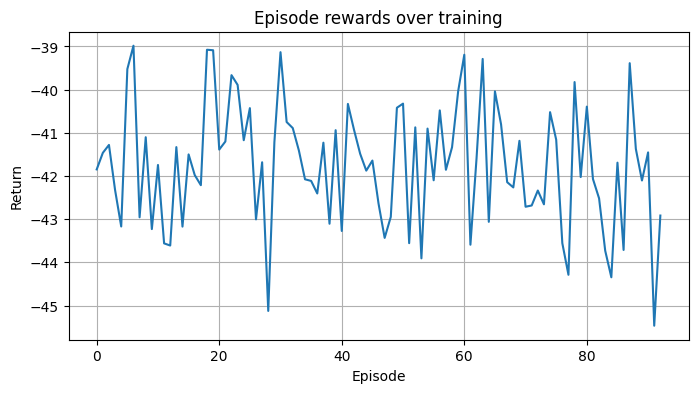

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 4))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Episode rewards over training")
plt.grid(True)
plt.show()

In [3]:
critic_loss

0.0016103945672512054

In [ ]:
import sys
sys.path.append("..")
from torch.nn.functional import mse_loss
from torch import optim
from torch.nn.utils import clip_grad_norm_
from config import Config
from utils import polyak_update


config = Config(
    state_dim = 8,
    action_dim = 1,
    action_tanh = False,
    num_encoders = 8,
    tree_depth = 4,
    actor_num_hidden_layers = 3,
    embed_dim = 64,
    discount_rate = 0.97,
    polyak_factor = 0.01,
    batch_size = 256,
    num_episodes = 1,
    replay_buffer_size = 5000,
    learning_rate = 1e-3,
    noise_std = 0.1,
    noise_std_min = 0.0001,
    noise_std_decay = 0.9995,
    add_frequency = 1.0,
    update_interval = 10,
)

actor = Actor(config, rng)
optimizer = optim.Adam(actor.parameters(), lr = 1e-3)

for i in range(100000):
    state = torch.rand(config.batch_size, 8)
    # next_state = torch.rand(config.batch_size, 8)
    # _, next_q_value = actor.forward(next_state)
    target = state.norm(dim = -1, keepdim = True) # + 0.5 * next_q_value

    module_idx = rng.integers(0, len(actor._online_models))
    _, pred = actor.forward(state, module_idx = module_idx)
    
    loss = mse_loss(pred, target)
    loss.backward()
    clip_grad_norm_(actor._online_models[module_idx].parameters(), max_norm = 1.0)
    optimizer.step()
    optimizer.zero_grad(set_to_none = True)
    polyak_update(actor._target_models[module_idx], actor._online_models[module_idx], config.polyak_factor)

    if i % 100 == 0:
        print(f"loss: {loss.item():.8f}, pred: {pred.mean().item():.8f}, target: {target.mean().item():.8f}")

TypeError: Config.__init__() got an unexpected keyword argument 'num_hidden_layers'. Did you mean 'actor_num_hidden_layers'?

In [ ]:
from collections import deque

train_batch_size = config.batch_size

recent = deque()

episode_rewards = []

train_updates = 0
print_interval = 10

for episode in trange(config.num_episodes):
    state, _ = env.reset(seed = episode)
    state = torch.tensor(state, dtype = torch.float32, device = device).unsqueeze(0)
    episode_reward = 0.0
    terminated = False
    truncated = False


    while not terminated and not truncated:
        with torch.no_grad():
            actor_embeds, action = actor.forward(state)

        next_state, reward, terminated, truncated, _ = env.step(action[0].cpu().numpy())
        next_state_t = torch.tensor(next_state, dtype = torch.float32, device = device).unsqueeze(0)
        reward_t = torch.tensor([[reward]], dtype = torch.float32, device = device)
        done_t = torch.tensor([[float(terminated or truncated)]], dtype = torch.float32, device = device)

        recent.append((state, action, reward_t, done_t, next_state_t))
        state = next_state_t
        episode_reward += float(reward)

        if len(recent) >= train_batch_size:
            recent_batch = list(recent)[-train_batch_size:]

            batch_state = torch.cat([x[0] for x in recent_batch], dim = 0)
            batch_action = torch.cat([x[1] for x in recent_batch], dim = 0)
            batch_reward = torch.cat([x[2] for x in recent_batch], dim = 0)
            batch_done = torch.cat([x[3] for x in recent_batch], dim = 0)
            batch_next_state = torch.cat([x[4] for x in recent_batch], dim = 0)

            with torch.no_grad():
                batch_actor_embeds, _ = actor.forward(batch_state)

            critic_loss, target_q_value, module_idx = critic.train(
                actor = actor,
                state = batch_state,
                actor_embeds = batch_actor_embeds,
                action = batch_action,
                reward = batch_reward,
                done = batch_done,
                next_state = batch_next_state,
            )
            actor_loss = actor.train(critic = critic, state = batch_state)

            train_updates += 1
            if train_updates % print_interval == 0:
                print(train_updates, critic_loss, actor_loss, target_q_value)

            recent.clear()

    episode_rewards.append(episode_reward)

episode_rewards

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 1/5000 [00:08<11:45:06,  8.46s/it]

10 0.021370232105255127 1.6873626708984375 -1.7164616584777832


  0%|          | 2/5000 [00:20<14:23:26, 10.37s/it]

20 0.021358080208301544 1.6508803367614746 -1.7130039930343628


...

  0%|          | 25/5000 [04:30<6:19:05,  4.57s/it]

200 0.021846432238817215 1.8101130723953247 -1.8374998569488525


  1%|          | 26/5000 [04:37<7:30:39,  5.44s/it]

210 0.030518950894474983 1.7471710443496704 -1.8454148769378662


  1%|          | 28/5000 [05:17<19:00:10, 13.76s/it]